## Data Loading

In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current device for computations: {device}")

if device.type == 'cpu':
    print("GPU is not currently enabled. To use GPU, go to 'Runtime' -> 'Change runtime type' and select 'GPU' as the hardware accelerator.")

Current device for computations: cuda


In [2]:
!git clone https://github.com/Krishna-web-hub/PD-lab

Cloning into 'PD-lab'...
remote: Enumerating objects: 2391, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 2391 (delta 8), reused 8 (delta 2), pack-reused 2365 (from 1)
Receiving objects: 100% (2391/2391), 44.68 MiB | 23.17 MiB/s, done.
Resolving deltas: 100% (13/13), done.


## Data Trans formations

**Train Data**


In [3]:
import os
import torch
from torchvision import datasets, transforms
from torchvision.utils import save_image
from tqdm import tqdm # pip install tqdm for a progress bar

# 1. Define your paths
# Ensure your source data is in subfolders by class (e.g., source_data/cats/, source_data/dogs/)
source_dir = '/content/PD-lab/dataset/train'
target_dir = '50000_images_train'

# 2. Define a heavy augmentation pipeline
# Because we need 50 variations per image, we need diverse, heavy transformations
aug_pipeline = transforms.Compose([
    transforms.RandomRotation(degrees=45),
    # Affine handles translation (shifting), scaling (zooming), and shearing
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),

    # Essential: Convert to PyTorch Tensor so we can save it
    transforms.ToTensor()
])

# 3. Load the dataset
# We apply the pipeline here. Every time an image is accessed, it gets randomly transformed.
dataset = datasets.ImageFolder(root=source_dir, transform=aug_pipeline)

# 4. Create target directories to match the original class structure
os.makedirs(target_dir, exist_ok=True)
for class_name in dataset.classes:
    os.makedirs(os.path.join(target_dir, class_name), exist_ok=True)

# 5. Set the multiplier to reach your goal
# 1,000 original images * 50 variations = 50,000 new images
variations_per_image = 50

print(f"Starting generation of {len(dataset) * variations_per_image} augmented images...")

# 6. Generate and save the images
# We iterate through the original dataset 1 image at a time
for i in tqdm(range(len(dataset)), desc="Processing original images"):

    # Get the original file path and class name to keep our saved files organized
    original_path, class_idx = dataset.samples[i]
    class_name = dataset.classes[class_idx]

    # Extract just the filename without the extension (e.g., 'image_01')
    base_filename = os.path.basename(original_path).split('.')[0]

    # Generate 50 unique variations for this specific image
    for v in range(variations_per_image):
        # Accessing dataset[i] triggers the random aug_pipeline fresh every single time
        aug_tensor, _ = dataset[i]

        # Create a new filename (e.g., 'image_01_aug_0.jpg')
        new_filename = f"{base_filename}_aug_{v}.jpg"
        save_path = os.path.join(target_dir, class_name, new_filename)

        # Save the tensor as a JPEG/PNG file to the new path
        save_image(aug_tensor, save_path)

print(f"Success! All images saved to: {target_dir}")

Starting generation of 52700 augmented images...


Processing original images: 100%|██████████| 1054/1054 [08:11<00:00,  2.15it/s]

Success! All images saved to: 50000_images_train


**Test File**


In [4]:
import os
from PIL import Image
from torchvision import transforms

# 1. Define your directories
# Replace these with your actual folder paths
input_dir = '/content/PD-lab/dataset/val'
output_dir = '18000_images_val'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# 2. Define your augmentation pipeline
# Notice we DO NOT use ToTensor() or Normalize() here.
# We want to keep the images in standard pixel format to save them as JPGs/PNGs.
augmenter = transforms.Compose([
    transforms.RandomRotation(degrees=30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomResizedCrop(size=224, scale=(0.7, 1.0)) # Assuming 224x224 is your target size
])

# 3. Set the multiplier
variations_per_image = 18 # 1 original + 17 augmented = 18 total

# 4. Loop through the dataset and generate files
valid_extensions = ('.png', '.jpg', '.jpeg')
image_files = [f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)]

print(f"Found {len(image_files)} images. Starting augmentation...")

for filename in image_files:
    image_path = os.path.join(input_dir, filename)

    try:
        # Load the original image
        img = Image.open(image_path).convert('RGB')

        # Split filename and extension (e.g., 'dog', '.jpg')
        base_name, ext = os.path.splitext(filename)

        # Save a copy of the original image to the new dataset folder
        img.save(os.path.join(output_dir, f"{base_name}_orig{ext}"))

        # Generate and save the 17 augmented versions
        for i in range(1, variations_per_image):
            # Apply the random transforms
            augmented_img = augmenter(img)

            # Create a unique filename for each variation
            new_filename = f"{base_name}_aug_{i}{ext}"
            save_path = os.path.join(output_dir, new_filename)

            # Save to disk
            augmented_img.save(save_path)

    except Exception as e:
        print(f"Error processing {filename}: {e}")

print(f"Done! Check your new directory: {output_dir}")

Found 0 images. Starting augmentation...
Done! Check your new directory: 18000_images_val


In [5]:
# showing data of training
!ls -R /content/50000_images_train | head -n 50

/content/50000_images_train:
ai_detection
spoilage_detection

/content/50000_images_train/ai_detection:
1_good food (1)_aug_0.jpg
1_good food (1)_aug_10.jpg
1_good food (1)_aug_11.jpg
1_good food (1)_aug_12.jpg
1_good food (1)_aug_13.jpg
1_good food (1)_aug_14.jpg
1_good food (1)_aug_15.jpg
1_good food (1)_aug_16.jpg
1_good food (1)_aug_17.jpg
1_good food (1)_aug_18.jpg
1_good food (1)_aug_19.jpg
1_good food (1)_aug_1.jpg
1_good food (1)_aug_20.jpg
1_good food (1)_aug_21.jpg
1_good food (1)_aug_22.jpg
1_good food (1)_aug_23.jpg
1_good food (1)_aug_24.jpg
1_good food (1)_aug_25.jpg
1_good food (1)_aug_26.jpg
1_good food (1)_aug_27.jpg
1_good food (1)_aug_28.jpg
1_good food (1)_aug_29.jpg
1_good food (1)_aug_2.jpg
1_good food (1)_aug_30.jpg
1_good food (1)_aug_31.jpg
1_good food (1)_aug_32.jpg
1_good food (1)_aug_33.jpg
1_good food (1)_aug_34.jpg
1_good food (1)_aug_35.jpg
1_good food (1)_aug_36.jpg
1_good food (1)_aug_37.jpg
1_good food (1)_aug_38.jpg
1_good food (1)_aug_39.jpg
1_good f

In [6]:
import os
import torch
from torchvision import datasets, transforms
from torchvision.utils import save_image
from torch.utils.data import random_split
from tqdm import tqdm

# 1. Define paths
source_augmented_train_dir = '/content/50000_images_train'
new_train_output_dir = 'split_train_data'
new_val_output_dir = 'split_val_data_15000'

# A simple transform to load images as tensors for saving with save_image
load_transform = transforms.ToTensor()

# Load the existing augmented dataset
print(f"Loading existing augmented training data from: {source_augmented_train_dir}")
full_augmented_dataset = datasets.ImageFolder(root=source_augmented_train_dir, transform=load_transform)

# Get class names and mapping
classes = full_augmented_dataset.classes
class_to_idx = full_augmented_dataset.class_to_idx

# Define split sizes
total_images = len(full_augmented_dataset)
val_size = 15000

if total_images < val_size:
    print(f"Warning: Desired validation size ({val_size}) is greater than total available images ({total_images}). Setting val_size to {total_images}.")
    val_size = total_images

train_size = total_images - val_size

print(f"Total images in original augmented set: {total_images}")
print(f"New training set size: {train_size}")
print(f"New validation set size: {val_size}")

# Perform random split
# Using a fixed seed for reproducibility
train_subset, val_subset = random_split(full_augmented_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# Create new output directories with class subfolders
print(f"Creating new directories: {new_train_output_dir} and {new_val_output_dir}")
os.makedirs(new_train_output_dir, exist_ok=True)
os.makedirs(new_val_output_dir, exist_ok=True)

for cls_name in classes:
    os.makedirs(os.path.join(new_train_output_dir, cls_name), exist_ok=True)
    os.makedirs(os.path.join(new_val_output_dir, cls_name), exist_ok=True)

# Save new training subset
print(f"Saving {len(train_subset)} images to new training data directory: {new_train_output_dir}")
for idx in tqdm(range(len(train_subset)), desc="Saving new training data"):
    img_tensor, class_idx = train_subset[idx]
    # Retrieve original path to reconstruct filename for saving
    original_idx_in_full_dataset = train_subset.indices[idx]
    original_path, _ = full_augmented_dataset.samples[original_idx_in_full_dataset]
    class_name = classes[class_idx]
    base_filename = os.path.basename(original_path)

    save_image(img_tensor, os.path.join(new_train_output_dir, class_name, base_filename))

# Save new validation subset
print(f"Saving {len(val_subset)} images to new validation data directory: {new_val_output_dir}")
for idx in tqdm(range(len(val_subset)), desc="Saving new validation data"):
    img_tensor, class_idx = val_subset[idx]
    original_idx_in_full_dataset = val_subset.indices[idx]
    original_path, _ = full_augmented_dataset.samples[original_idx_in_full_dataset]
    class_name = classes[class_idx]
    base_filename = os.path.basename(original_path)

    save_image(img_tensor, os.path.join(new_val_output_dir, class_name, base_filename))

print("-------------------------------------------------------------------------------------------------------")
print(f"Data splitting complete! ")
print(f"New training data is in: {new_train_output_dir} (containing {len(train_subset)} images)")
print(f"New validation data is in: {new_val_output_dir} (containing {len(val_subset)} images)")
print("-------------------------------------------------------------------------------------------------------")
print("IMPORTANT: Please update your training cell (cell iWsaZsYnQB5b) with the new paths:")
print(f"train_path = '{new_train_output_dir}'")
print(f"val_path = '{new_val_output_dir}'")

Loading existing augmented training data from: /content/50000_images_train
Total images in original augmented set: 50850
New training set size: 35850
New validation set size: 15000
Creating new directories: split_train_data and split_val_data_15000
Saving 35850 images to new training data directory: split_train_data


Saving new training data: 100%|██████████| 35850/35850 [01:34<00:00, 379.63it/s]


Saving 15000 images to new validation data directory: split_val_data_15000


Saving new validation data: 100%|██████████| 15000/15000 [00:39<00:00, 380.42it/s]

-------------------------------------------------------------------------------------------------------
Data splitting complete! 
New training data is in: split_train_data (containing 35850 images)
New validation data is in: split_val_data_15000 (containing 15000 images)
-------------------------------------------------------------------------------------------------------
IMPORTANT: Please update your training cell (cell iWsaZsYnQB5b) with the new paths:
train_path = 'split_train_data'
val_path = 'split_val_data_15000'


## Training

Using device: cuda
Found 2 classes: ['ai_detection', 'spoilage_detection']
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 171MB/s]


Starting training for 5 epochs...
Epoch [1/5] Train Loss: 0.7238, Train Acc: 58.63% | Val Loss: 0.7202, Val Acc: 59.69%
Epoch [2/5] Train Loss: 0.7231, Train Acc: 59.35% | Val Loss: 0.6832, Val Acc: 60.21%
Epoch [3/5] Train Loss: 0.7182, Train Acc: 59.83% | Val Loss: 0.6935, Val Acc: 61.88%
Epoch [4/5] Train Loss: 0.7244, Train Acc: 59.46% | Val Loss: 0.7214, Val Acc: 60.89%
Epoch [5/5] Train Loss: 0.7255, Train Acc: 59.85% | Val Loss: 0.7139, Val Acc: 60.39%
Training Complete!


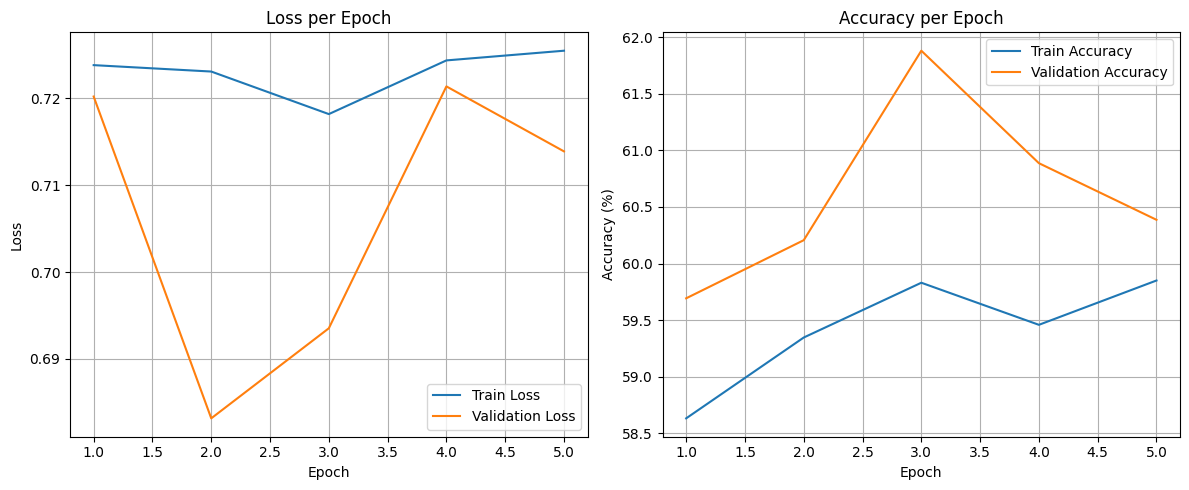

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Setup Device & Paths
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Assuming these are your already augmented train and validation datasets
train_path = '/content/50000_images_train'
val_path = '/content/split_val_data_15000' # Using this as the 'test' or validation set

# ---------------------------------------------------------
# 2. Define Transforms (CRITICAL FOR ViT)
# ---------------------------------------------------------
# Vision Transformers typically expect 224x224 images and ImageNet normalization
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Basic data augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ---------------------------------------------------------
# 3. Load Datasets and DataLoaders
# ---------------------------------------------------------
try:
    train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)
    val_dataset = datasets.ImageFolder(root=val_path, transform=val_transform)
except FileNotFoundError as e:
    print(f"Error loading dataset: {e}")
    print("Please ensure that the directories exist and contain class subfolders with images.")
    print(f"Expected train data at: {train_path}")
    print(f"Expected validation data at: {val_path}")
    raise # Re-raise the error after printing context

# Batch size of 32 is standard, reduce to 16 if you get Out Of Memory (OOM) errors
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print(f"Found {num_classes} classes: {train_dataset.classes}")

# ---------------------------------------------------------
# 4. Load Pre-trained ViT Model & Modify Head
# ---------------------------------------------------------
# Load the pre-trained Vision Transformer
weights = models.ViT_B_16_Weights.DEFAULT
model = models.vit_b_16(weights=weights)

# Freeze the base model parameters so we only train the final classification head
for param in model.parameters():
    param.requires_grad = False

# Replace the classification head to match your number of classes
# ViT's head is stored in `model.heads.head`
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, num_classes)

# Move the model to GPU (if available)
model = model.to(device)

# ---------------------------------------------------------
# 5. Define Loss Function and Optimizer
# ---------------------------------------------------------
criterion = nn.CrossEntropyLoss()
learning_rate = 0.005 # User requested a high learning rate
optimizer = optim.Adam(model.heads.head.parameters(), lr=learning_rate)

# ---------------------------------------------------------
# 6. Training and Evaluation Loop
# ---------------------------------------------------------
epochs = 5# You can adjust this for longer training

# Lists to store metrics for plotting
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

print(f"Starting training for {epochs} epochs...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # --- EVALUATION PHASE ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = (correct_val / total_val) * 100

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # Print Epoch Results
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

print("Training Complete!")

# ---------------------------------------------------------
# 7. Plotting Accuracy and Loss Curves
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Model Download

In [8]:
import torch
import os

# Define the path where you want to save the model
model_save_path = 'vit_food_detection_model.pth'

# Ensure the model variable 'model' is available from previous cells
# If not, you would need to re-initialize and load weights.
if 'model' in locals():
    # Save the model's state dictionary
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved successfully to {model_save_path}")
    print("You can now download this file from the Colab file browser (left sidebar) or using the following command:")
    print(f"!cp {model_save_path} /content/drive/MyDrive/ # To save to Google Drive")
    print(f"from google.colab import files\nfiles.download('{model_save_path}') # To download directly")
else:
    print("Error: 'model' variable not found. Please ensure the training cell was run successfully.")


Model saved successfully to vit_food_detection_model.pth
You can now download this file from the Colab file browser (left sidebar) or using the following command:
!cp vit_food_detection_model.pth /content/drive/MyDrive/ # To save to Google Drive
from google.colab import files
files.download('vit_food_detection_model.pth') # To download directly


In [ ]:
from google.colab import files
files.download('vit_food_detection_model.pth')

## Testing Model on 15k_Val_data

In [9]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Ensure the device is set up (should be from previous cells)
if 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device re-initialized to: {device}")

# Ensure the model is loaded and in evaluation mode
if 'model' not in globals():
    print("Model not found in global scope. Attempting to load from saved .pth")
    # This part would need the model architecture to be re-defined if the kernel restarted
    # For this execution, we assume 'model' is available from previous training cell
    raise RuntimeError("Model 'model' not found. Please run training cell or reload model.")

model.eval() # Set the model to evaluation mode

# Define the path to the validation data
val_path = '/content/split_val_data_15000'

# Reuse the validation transforms from the training cell (cell iWsaZsYnQB5b)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the validation dataset and create a DataLoader
try:
    val_dataset = datasets.ImageFolder(root=val_path, transform=val_transform)
    # Reuse batch_size from the training cell if available, otherwise default
    batch_size = globals().get('batch_size', 32)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    num_classes = len(val_dataset.classes)
    print(f"Found {num_classes} classes for validation: {val_dataset.classes}")
except FileNotFoundError as e:
    print(f"Error loading validation dataset: {e}")
    print(f"Please ensure the directory exists: {val_path}")
    raise # Re-raise the error after printing context

# Reuse the criterion from the training cell
criterion = globals().get('criterion', nn.CrossEntropyLoss())

print(f"Starting evaluation on {len(val_dataset)} images...")

val_loss = 0.0
correct_val = 0
total_val = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        val_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_val += labels.size(0)
        correct_val += (predicted == labels).sum().item()

epoch_val_loss = val_loss / len(val_dataset)
epoch_val_acc = (correct_val / total_val) * 100

print("--------------------------------------------------")
print(f"Validation Results:")
print(f"  Loss: {epoch_val_loss:.4f}")
print(f"  Accuracy: {epoch_val_acc:.2f}%")
print("--------------------------------------------------")


Found 2 classes for validation: ['ai_detection', 'spoilage_detection']
Starting evaluation on 15000 images...
--------------------------------------------------
Validation Results:
  Loss: 0.7139
  Accuracy: 60.39%
--------------------------------------------------


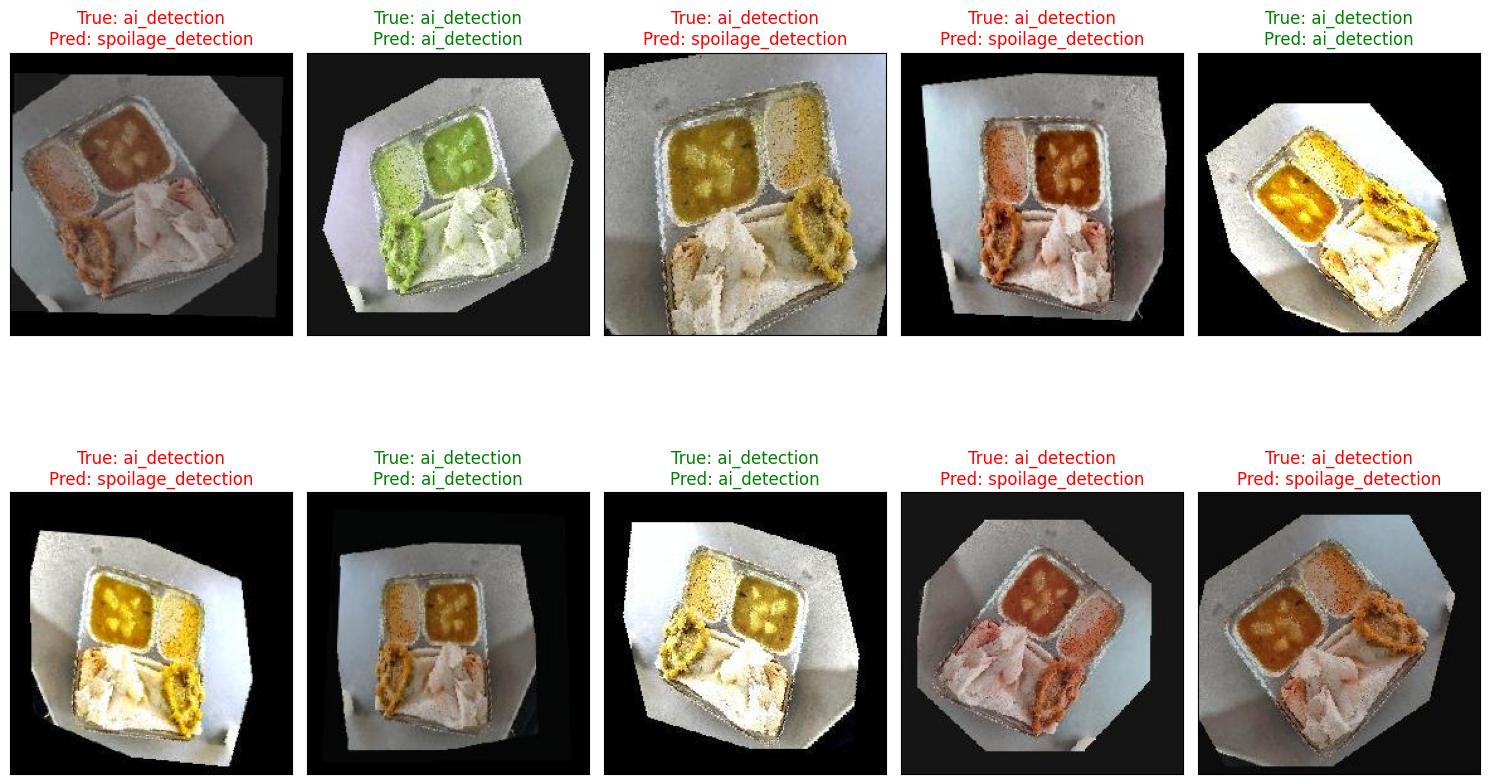

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure the model is in evaluation mode
if 'model' not in globals():
    print("Model not found. Please ensure the training cell was run.")
    # Optionally, load the model if it was saved
    # model = models.vit_b_16(weights=None) # Re-initialize architecture
    # model.heads.head = torch.nn.Linear(model.heads.head.in_features, num_classes)
    # model.load_state_dict(torch.load('vit_food_detection_model.pth', map_location=device))
    # model.to(device)
    raise RuntimeError("Model 'model' not found.")
model.eval()

# Ensure val_loader and val_dataset are available
if 'val_loader' not in globals() or 'val_dataset' not in globals():
    print("Validation DataLoader or Dataset not found. Please run the testing cell (NhfCxxDYSRbx) first.")
    raise RuntimeError("Validation DataLoader/Dataset not found.")

classes = val_dataset.classes

# Get a batch of test images and labels
dataiter = iter(val_loader)
images, labels = next(dataiter)

# Move images to the device and make predictions
images = images.to(device)
labels = labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Convert tensors to numpy arrays for plotting
images = images.cpu().numpy()
labels = labels.cpu().numpy()
predicted = predicted.cpu().numpy()

# Function to unnormalize and transpose image for matplotlib display
def imshow(img):
    # Unnormalize: (img * std) + mean
    # ImageNet stats: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    mean = np.array([0.485, 0.456, 0.406]).reshape((3, 1, 1))
    std = np.array([0.229, 0.224, 0.225]).reshape((3, 1, 1))
    img = img * std + mean
    img = np.clip(img, 0, 1) # Clip values to [0, 1]
    plt.imshow(np.transpose(img, (1, 2, 0))) # Convert from (C, H, W) to (H, W, C)

# Plot the images with predictions
fig = plt.figure(figsize=(15, 10))
for idx in np.arange(10):
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    color = 'green' if predicted[idx] == labels[idx] else 'red'
    ax.set_title(f"True: {classes[labels[idx]]}\nPred: {classes[predicted[idx]]}", color=color)
plt.tight_layout()
plt.show()


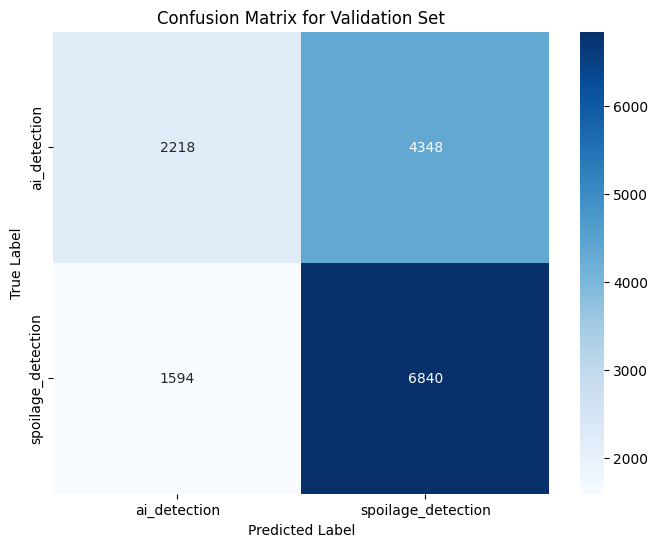

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure the model is in evaluation mode
if 'model' not in globals():
    print("Model not found. Please ensure the training cell was run.")
    raise RuntimeError("Model 'model' not found.")
model.eval()

# Ensure val_loader and val_dataset are available
if 'val_loader' not in globals() or 'val_dataset' not in globals():
    print("Validation DataLoader or Dataset not found. Please run the testing cell (NhfCxxDYSRbx) first.")
    raise RuntimeError("Validation DataLoader/Dataset not found.")

all_preds = []
all_labels = []

print("Collecting predictions for confusion matrix...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Get class names from the dataset
classes = val_dataset.classes

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Validation Set')
plt.show()


In [12]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Ensure the device is set up (should be from previous cells)
if 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device re-initialized to: {device}")

# Ensure the model is loaded and in evaluation mode
if 'model' not in globals():
    print("Model not found in global scope. Attempting to load from saved .pth")
    # This part would need the model architecture to be re-defined if the kernel restarted
    # For this execution, we assume 'model' is available from previous training cell
    raise RuntimeError("Model 'model' not found. Please run training cell or reload model.")

model.eval() # Set the model to evaluation mode

# Define the path to the data for testing
val_path = '/content/50000_images_train'

# Reuse the validation transforms from the training cell (cell iWsaZsYnQB5b)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the dataset and create a DataLoader
try:
    val_dataset = datasets.ImageFolder(root=val_path, transform=val_transform)
    # Reuse batch_size from the training cell if available, otherwise default
    batch_size = globals().get('batch_size', 32)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    num_classes = len(val_dataset.classes)
    print(f"Found {num_classes} classes for testing: {val_dataset.classes}")
except FileNotFoundError as e:
    print(f"Error loading dataset for testing: {e}")
    print(f"Please ensure the directory exists: {val_path}")
    raise # Re-raise the error after printing context

# Reuse the criterion from the training cell
criterion = globals().get('criterion', nn.CrossEntropyLoss())

print(f"Starting evaluation on {len(val_dataset)} images...")

val_loss = 0.0
correct_val = 0
total_val = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        val_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_val += labels.size(0)
        correct_val += (predicted == labels).sum().item()

epoch_val_loss = val_loss / len(val_dataset)
epoch_val_acc = (correct_val / total_val) * 100

print("--------------------------------------------------")
print(f"Testing Results on {val_path}:")
print(f"  Loss: {epoch_val_loss:.4f}")
print(f"  Accuracy: {epoch_val_acc:.2f}%")
print("--------------------------------------------------")

Found 2 classes for testing: ['ai_detection', 'spoilage_detection']
Starting evaluation on 50850 images...
--------------------------------------------------
Testing Results on /content/50000_images_train:
  Loss: 0.7094
  Accuracy: 60.62%
--------------------------------------------------
